In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier


# llamar al documento

datos_f = pd.read_csv('mushrooms.csv')

print('=' * 80)

# copia dataset

datos_f_copia = datos_f.copy()
datos_f_copia

print("=" * 80)

# Tipos de cada columna
print(datos_f_copia.dtypes)

print("=" * 80)

# .shape()

datos_f_copia.shape

print("=" * 80)

# describe

datos_f_copia.describe()

print("=" * 80)

# Cuántos valores faltan en cada columna. Fundamental para decidir la estrategia de imputación.

# datos_f_copia.isna().sum()

# print("=" * 80)

datos_f_copia.isnull().sum()



class                       str
cap-shape                   str
cap-surface                 str
cap-color                   str
bruises                     str
odor                        str
gill-attachment             str
gill-spacing                str
gill-size                   str
gill-color                  str
stalk-shape                 str
stalk-root                  str
stalk-surface-above-ring    str
stalk-surface-below-ring    str
stalk-color-above-ring      str
stalk-color-below-ring      str
veil-type                   str
veil-color                  str
ring-number                 str
ring-type                   str
spore-print-color           str
population                  str
habitat                     str
dtype: object


class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [ ]:
# analisis de cada columna, para conocer diferencias:
# venenoso o comestible 
sns.countplot(data=datos_f_copia, x='class')

In [ ]:
# Manchas si/ no
sns.countplot(data=datos_f_copia, x='bruises', hue='class')

In [ ]:
# olor
sns.countplot(data=datos_f_copia, x='odor', hue='class')

In [ ]:
# Tamaño lamelas
sns.countplot(data=datos_f_copia, x='gill-size', hue='class')

In [ ]:
# Color de lamelas
sns.countplot(data=datos_f_copia, x='gill-color', hue='class')

In [ ]:
# Superficie del pie sobre el anillo
sns.countplot(data=datos_f_copia, x= 'stalk-surface-above-ring', hue='class')

In [ ]:
# Superficie del pie bajo el anillo
sns.countplot(data=datos_f_copia, x='stalk-surface-below-ring', hue='class')

In [ ]:
# revision 

sns.countplot(data=datos_f_copia, x='stalk-color-above-ring', hue= 'class')

In [ ]:
# Dato 15
sns.countplot(data=datos_f_copia, x='stalk-color-below-ring', hue= 'class')

In [ ]:
# Tipo de anillo
sns.countplot(data=datos_f_copia, x='ring-type', hue='class')

In [ ]:
# Color de la espora impresa
sns.countplot(data=datos_f_copia, x='spore-print-color', hue='class')

In [ ]:
# población
sns.countplot(data=datos_f_copia, x='population', hue='class')

In [ ]:
# Hábitat
sns.countplot(data=datos_f_copia, x='habitat', hue='class')

In [ ]:
# segundo paso, será comparar una columna con la caracteristica primordial que es venenoso o comestible. 

sns.countplot(data=datos_f_copia, x='odor', hue='class')

In [ ]:
sns.countplot(data=datos_f_copia, x='population', hue='class', 
            order=datos_f_copia['population'].value_counts().index)
plt.xticks(rotation=45)

In [ ]:
sns.countplot(data=datos_f_copia, x='habitat', hue='class', 
            order=datos_f_copia['habitat'].value_counts().index)
plt.xticks(rotation=45)

In [ ]:
sns.countplot(data=datos_f_copia, x='ring-type', hue='class', 
            order=datos_f_copia['ring-type'].value_counts().index)
plt.xticks(rotation=45)

In [ ]:
# color de esporas en impresion
sns.countplot(data=datos_f_copia, x='spore-print-color', hue='class', 
            order=datos_f_copia['spore-print-color'].value_counts().index)
plt.xticks(rotation=45)

In [2]:
# unificar columnas 12 y 13
# Crea una columna que es True si cualquiera de las dos es 'k'
datos_f_copia['stalk_silky'] = (datos_f_copia['stalk-surface-above-ring'] == 'k') | (datos_f_copia['stalk-surface-below-ring'] == 'k')

# unificar columnas 14 y 15



# Transformar str a int
# X = pd.get_dummies(X, columns=['island'])
# pd.get_dummies('odor', )

In [3]:
# Definimos los colores que solo son para venenosos

colors_stalk_ring = ['b', 'c', 'y'] 

# Creamos una columna que diga "Peligro" si ese color aparece en cualquiera de los dos tramos del pie
datos_f_copia['color_silky_alert_poison'] = (datos_f_copia['stalk-color-above-ring'].isin(colors_stalk_ring)) | \
                            (datos_f_copia['stalk-color-below-ring'].isin(colors_stalk_ring))

# Convertimos a 1 (Peligro, poisonous) y 0 (Normal)
datos_f_copia['color_silky_alert_poison'] = datos_f_copia['color_silky_alert_poison'].astype(int)

# Me ha entregado un 2% de peligroso, lo podemos ver de la siguiente forma: 
# ¿cuántos de ese 2% son venenosos (p) y cuántos comestibles (e)?
print(datos_f_copia[datos_f_copia['color_silky_alert_poison'] == 1]['class'].value_counts())

# https://cursos.kobalto.es/teoria/pandas-advanced#method=groupby

# Vamos a ver la precisión de tu nueva variable, 
counts = datos_f_copia.groupby('color_silky_alert_poison')['class'].value_counts(normalize=True) * 100
print(counts)

class
p    780
Name: count, dtype: int64
color_silky_alert_poison  class
0                         e         57.298475
                          p         42.701525
1                         p        100.000000
Name: proportion, dtype: float64


In [4]:
# Label Encodering (Pasar valores categóricos a numéricos)
# copia limpia para LabelEncoder | https://cursos.kobalto.es/teoria/sklearn-preprocesamiento#method=label_encoder
datos_f_copia_2= datos_f_copia.copy()
datos_f_copia_2

# variable y

y= datos_f_copia_2['class']

# Añadir codificador:

le= LabelEncoder()
y_encoded = le.fit_transform(y)

# Ahora creamos X

X = datos_f_copia_2.drop('class', axis=1)

# Ahora transformamos cada columna de X a números:
# Creamos nuestro traductor de X
le_X = LabelEncoder()

# Transformamos a través de bucle for:

for columna in X.columns:
    X[columna] = le_X.fit_transform(X[columna])

# 4. Comprobamos el resultado: aquí nos saldrá las primeras 5 filas de cada columna, 
# es para saber si se ha hecho bien con los números
print(X.head())




   cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0          5            2          4        1     6                1   
1          5            2          9        1     0                1   
2          0            2          8        1     3                1   
3          5            3          8        1     6                1   
4          5            2          3        0     5                1   

   gill-spacing  gill-size  gill-color  stalk-shape  ...  \
0             0          1           4            0  ...   
1             0          0           4            0  ...   
2             0          0           5            0  ...   
3             0          1           5            0  ...   
4             1          0           4            1  ...   

   stalk-color-below-ring  veil-type  veil-color  ring-number  ring-type  \
0                       7          0           2            1          4   
1                       7          0           2      

In [ ]:
# Para ver las columnas que tengo hasta el momento.
print(X.columns.tolist())

In [5]:
# 1. Definimos la lista exacta de las columnas que queremos conservar
columnas_elegidas = [
    'cap-shape', 
    'cap-color', 
    'bruises', 
    'odor', 
    'gill-attachment', 
    'gill-spacing', 
    'gill-size', 
    'gill-color',
    'stalk_silky',  # <-- Pon aquí el nombre exacto que le diste a esta
    'color_silky_alert_poison'   # <-- Pon aquí el nombre exacto que le diste a esta
]

# 2. Le decimos a X que se quede SOLO con esas 10 columnas
X = X[columnas_elegidas]

# 3. Comprobamos que ahora sí está perfecto
print("¡Limpieza hecha!")
print(f"Número de columnas final: {X.shape[1]}")
print(X.columns.tolist())

¡Limpieza hecha!
Número de columnas final: 10
['cap-shape', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk_silky', 'color_silky_alert_poison']


In [11]:
# Hacemos el reparto definitivo de las 10 columnas y la respuesta class
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"¡Reparto oficial completado con éxito!")
print(f"Hongos para que el modelo estudie (X_train): {len(X_train)}")
print(f"Hongos que nos guardamos para el examen (X_test): {len(X_test)}")

¡Reparto oficial completado con éxito!
Hongos para que el modelo estudie (X_train): 6499
Hongos que nos guardamos para el examen (X_test): 1625


In [13]:
# 1. Traemos el modelo al laboratorio (fijamos el random_state para que no invente)
modelo_arbol = DecisionTreeClassifier(random_state=42)

# 2. ¡A estudiar! Le pasamos los datos de entrenamiento para que busque las reglas
modelo_arbol.fit(X_train, y_train)

print("¡Árbol entrenado con éxito! Ya se ha aprendido las reglas de tus 10 columnas.")

¡Árbol entrenado con éxito! Ya se ha aprendido las reglas de tus 10 columnas.


In [14]:
# 1. El modelo hace el examen (predice las respuestas para el grupo de test)
predicciones = modelo_arbol.predict(X_test)

# 2. Calculamos la nota final (el porcentaje de aciertos)
nota_final = accuracy_score(y_test, predicciones)

print(f"¡Examen terminado!")
print(f"La precisión del modelo es del: {nota_final * 100:.2f}%")
print("-" * 50)
print("Informe detallado:")
print(classification_report(y_test, predicciones))

¡Examen terminado!
La precisión del modelo es del: 99.94%
--------------------------------------------------
Informe detallado:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



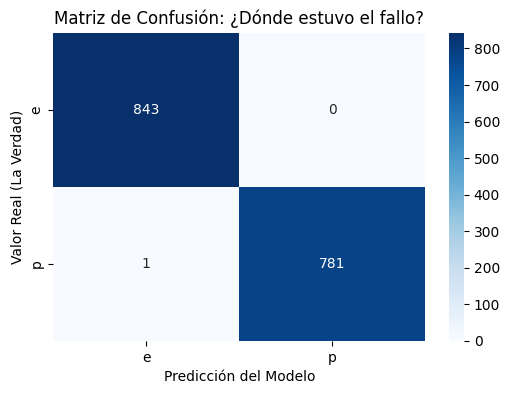

In [16]:
# Creamos la matriz de confusión
cm = confusion_matrix(y_test, predicciones)

# La pintamos bonita
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (La Verdad)')
plt.title('Matriz de Confusión: ¿Dónde estuvo el fallo?')
plt.show()

El resultado del analisis a través del arbol de desición, señala un aprendizaje por parte del algoritmo del 99, 94%. 